# NB03: Within-Species AMR × Environment

Test H4: within species that span multiple environments, do strains from
different niches carry different AMR genes?

884 species qualify (>=5 genomes in >=2 environments from NB01).

**Inputs:** `data/genome_environment.csv`, bakta_amr + gene_cluster (via Spark)

**Outputs:** `data/within_species_amr_environment.csv`, figures

In [1]:
import os
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore', category=FutureWarning)

_here = os.path.abspath('')
if os.path.basename(_here) == 'notebooks':
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))
elif os.path.exists(os.path.join(_here, 'projects', 'amr_environmental_resistome')):
    REPO = _here
else:
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))

PROJECT = os.path.join(REPO, 'projects', 'amr_environmental_resistome')
DATA = os.path.join(PROJECT, 'data')
FIGURES = os.path.join(PROJECT, 'figures')

# Load genome-level environment
genome_env = pd.read_csv(os.path.join(DATA, 'genome_environment.csv'))
genome_env = genome_env[genome_env['environment'] != 'unknown'].copy()
print(f'Classified genomes: {len(genome_env):,}')

Classified genomes: 262,055


## 1. Identify qualifying species and extract per-genome AMR

In [2]:
# Find species with >=5 genomes in >=2 environments
env_counts = genome_env.groupby(['gtdb_species_clade_id', 'environment']).size().reset_index(name='n')
env_counts_5 = env_counts[env_counts['n'] >= 5]
species_multi = env_counts_5.groupby('gtdb_species_clade_id').size()
qualifying_species = sorted(species_multi[species_multi >= 2].index)

print(f'Qualifying species (>=5 genomes in >=2 envs): {len(qualifying_species)}')

# Get genome IDs for qualifying species
qual_genomes = genome_env[genome_env['gtdb_species_clade_id'].isin(qualifying_species)]
print(f'Total genomes in qualifying species: {len(qual_genomes):,}')

Qualifying species (>=5 genomes in >=2 envs): 884
Total genomes in qualifying species: 155,480


In [3]:
# Extract per-genome AMR data via Spark
# For qualifying species: which AMR gene clusters are present in which genomes?
from berdl_notebook_utils.setup_spark_session import get_spark_session
spark = get_spark_session()

# Register qualifying species as temp view
spark.createDataFrame(
    [(s,) for s in qualifying_species], ['gtdb_species_clade_id']
).createOrReplaceTempView('qual_species')

# Get AMR gene clusters per species (from bakta_amr × gene_cluster)
# This gives us which AMR clusters exist in each qualifying species
species_amr_clusters = spark.sql("""
    SELECT a.gene_cluster_id, gc.gtdb_species_clade_id,
           gc.is_core, gc.is_auxiliary, gc.is_singleton,
           a.amr_gene, a.amr_product
    FROM kbase_ke_pangenome.bakta_amr a
    JOIN kbase_ke_pangenome.gene_cluster gc ON a.gene_cluster_id = gc.gene_cluster_id
    JOIN qual_species qs ON gc.gtdb_species_clade_id = qs.gtdb_species_clade_id
""").toPandas()

print(f'AMR clusters in qualifying species: {len(species_amr_clusters):,}')
print(f'Species covered: {species_amr_clusters["gtdb_species_clade_id"].nunique()}')

AMR clusters in qualifying species: 27,937
Species covered: 823


In [4]:
# For within-species analysis, we need per-GENOME AMR presence
# gene_genecluster_junction tells us which gene clusters are in which genomes
# But that's 1B rows — too large. Instead, use gene_cluster conservation status:
# - Core AMR clusters are in all genomes of the species (no within-species variation)
# - Accessory/singleton clusters vary between genomes

# For the within-species test, focus on ACCESSORY AMR clusters
# (core clusters don't vary within species by definition)
accessory_amr = species_amr_clusters[
    (species_amr_clusters['is_core'] == 0)
].copy()

print(f'Accessory AMR clusters in qualifying species: {len(accessory_amr):,}')
print(f'Species with accessory AMR: {accessory_amr["gtdb_species_clade_id"].nunique()}')

# Summary per species
species_amr_summary = species_amr_clusters.groupby('gtdb_species_clade_id').agg(
    n_total_amr=('gene_cluster_id', 'nunique'),
    n_core_amr=('is_core', 'sum'),
    n_accessory_amr=('is_core', lambda x: (x == 0).sum()),
).reset_index()

print(f'\nPer-species AMR summary:')
print(f'  Mean total: {species_amr_summary["n_total_amr"].mean():.1f}')
print(f'  Mean core: {species_amr_summary["n_core_amr"].mean():.1f}')
print(f'  Mean accessory: {species_amr_summary["n_accessory_amr"].mean():.1f}')

Accessory AMR clusters in qualifying species: 26,087
Species with accessory AMR: 804



Per-species AMR summary:
  Mean total: 33.9
  Mean core: 2.2
  Mean accessory: 31.7


## 2. Compare AMR profiles between environments within species

Since we can't efficiently get per-genome AMR presence for 884 species
(would require billion-row joins), we use a species-level approach:

For each qualifying species, compare the **fraction of genomes from each environment**
to the species' overall AMR profile. Species where clinical strains dominate
should have more accessory (acquired) AMR than species where environmental strains dominate.

In [5]:
# For each qualifying species: environment composition and AMR profile
within_species = []

for species in qualifying_species:
    sp_genomes = genome_env[genome_env['gtdb_species_clade_id'] == species]
    env_dist = sp_genomes['environment'].value_counts()
    total_genomes = len(sp_genomes)
    
    sp_amr = species_amr_summary[species_amr_summary['gtdb_species_clade_id'] == species]
    if len(sp_amr) == 0:
        continue
    
    n_total = sp_amr.iloc[0]['n_total_amr']
    n_core = sp_amr.iloc[0]['n_core_amr']
    n_acc = sp_amr.iloc[0]['n_accessory_amr']
    
    # Dominant and secondary environments
    envs_5plus = env_dist[env_dist >= 5]
    if len(envs_5plus) < 2:
        continue
    
    dominant_env = envs_5plus.index[0]
    secondary_env = envs_5plus.index[1]
    
    # Clinical fraction
    clinical_frac = env_dist.get('clinical', 0) / total_genomes
    
    within_species.append({
        'species': species,
        'n_genomes': total_genomes,
        'n_environments': len(envs_5plus),
        'dominant_env': dominant_env,
        'dominant_n': envs_5plus.iloc[0],
        'secondary_env': secondary_env,
        'secondary_n': envs_5plus.iloc[1],
        'clinical_frac': clinical_frac,
        'n_total_amr': n_total,
        'n_core_amr': n_core,
        'n_accessory_amr': n_acc,
        'pct_accessory': n_acc / n_total * 100 if n_total > 0 else 0,
    })

ws_df = pd.DataFrame(within_species)
print(f'Species with within-species env data + AMR: {len(ws_df)}')
print(f'\nDominant environment distribution:')
print(ws_df['dominant_env'].value_counts().to_string())

Species with within-species env data + AMR: 823

Dominant environment distribution:
dominant_env
host_associated        219
clinical               199
other_environmental    196
human_gut              134
aquatic                 40
soil                    35


In [6]:
# H4 test: does clinical fraction predict accessory AMR fraction?
# Species with more clinical genomes should have more accessory (acquired) AMR

r, p = stats.spearmanr(ws_df['clinical_frac'], ws_df['pct_accessory'])
print(f'=== H4: Clinical fraction vs accessory AMR ===')
print(f'Spearman rho = {r:.4f}, p = {p:.4g}, N = {len(ws_df)}')

# Also test: clinical fraction vs total AMR count
r2, p2 = stats.spearmanr(ws_df['clinical_frac'], ws_df['n_total_amr'])
print(f'Clinical fraction vs total AMR: rho = {r2:.4f}, p = {p2:.4g}')

# Compare species where dominant env is clinical vs environmental
clinical_dom = ws_df[ws_df['dominant_env'] == 'clinical']
env_dom = ws_df[ws_df['dominant_env'].isin(['soil', 'aquatic', 'other_environmental'])]

print(f'\nClinical-dominated species: N={len(clinical_dom)}, '
      f'mean AMR={clinical_dom["n_total_amr"].mean():.1f}, '
      f'mean %acc={clinical_dom["pct_accessory"].mean():.1f}%')
print(f'Environmental-dominated species: N={len(env_dom)}, '
      f'mean AMR={env_dom["n_total_amr"].mean():.1f}, '
      f'mean %acc={env_dom["pct_accessory"].mean():.1f}%')

if len(clinical_dom) >= 5 and len(env_dom) >= 5:
    u, p3 = stats.mannwhitneyu(clinical_dom['n_total_amr'], env_dom['n_total_amr'],
                                alternative='greater')
    print(f'Clinical > Environmental total AMR: MWU p = {p3:.4g}')
    u, p4 = stats.mannwhitneyu(clinical_dom['pct_accessory'], env_dom['pct_accessory'],
                                alternative='greater')
    print(f'Clinical > Environmental %accessory: MWU p = {p4:.4g}')

=== H4: Clinical fraction vs accessory AMR ===
Spearman rho = 0.0645, p = 0.06445, N = 823
Clinical fraction vs total AMR: rho = 0.4650, p = 2.211e-45

Clinical-dominated species: N=199, mean AMR=72.9, mean %acc=93.6%
Environmental-dominated species: N=271, mean AMR=16.4, mean %acc=81.7%
Clinical > Environmental total AMR: MWU p = 2.006e-18
Clinical > Environmental %accessory: MWU p = 0.004307


## 3. Case studies: deeply-sampled species

In [7]:
# Top species by genome count in multiple environments
top_species = ws_df.nlargest(20, 'n_genomes')

print(f'=== Top 20 species by genome count in multiple environments ===')
for _, row in top_species.iterrows():
    sp_short = row['species'].split('--')[0].replace('s__', '')
    print(f'  {sp_short:40s}: {row["n_genomes"]:6,} genomes, '
          f'{row["n_environments"]} envs, {row["n_total_amr"]:3.0f} AMR ({row["pct_accessory"]:.0f}% acc), '
          f'dom={row["dominant_env"]}')

=== Top 20 species by genome count in multiple environments ===
  Klebsiella_pneumoniae                   : 13,637 genomes, 6 envs, 1115 AMR (100% acc), dom=clinical
  Staphylococcus_aureus                   : 13,274 genomes, 6 envs, 642 AMR (99% acc), dom=clinical
  Salmonella_enterica                     : 10,097 genomes, 6 envs, 836 AMR (99% acc), dom=host_associated
  Streptococcus_pneumoniae                :  7,944 genomes, 3 envs,  59 AMR (98% acc), dom=clinical
  Mycobacterium_tuberculosis              :  6,673 genomes, 3 envs,  44 AMR (91% acc), dom=clinical
  Acinetobacter_baumannii                 :  5,936 genomes, 6 envs, 381 AMR (98% acc), dom=clinical
  Pseudomonas_aeruginosa                  :  5,759 genomes, 6 envs, 533 AMR (99% acc), dom=clinical
  Enterococcus_B_faecium                  :  2,343 genomes, 5 envs, 260 AMR (99% acc), dom=clinical
  Enterobacter_hormaechei_A               :  2,328 genomes, 6 envs, 537 AMR (100% acc), dom=clinical
  Campylobacter_D_jejuni  

In [8]:
# Detailed case study: A. baumannii (most clinical genomes)
# Show environment composition and AMR for the top 5 most genome-rich species
case_studies = ws_df.nlargest(5, 'n_genomes')['species'].tolist()

case_data = []
for species in case_studies:
    sp_genomes = genome_env[genome_env['gtdb_species_clade_id'] == species]
    env_dist = sp_genomes['environment'].value_counts()
    sp_amr = species_amr_summary[species_amr_summary['gtdb_species_clade_id'] == species].iloc[0]
    
    sp_short = species.split('--')[0].replace('s__', '')
    print(f'\n=== {sp_short} ===')
    print(f'  Genomes: {len(sp_genomes):,}')
    print(f'  AMR clusters: {sp_amr["n_total_amr"]:.0f} total, '
          f'{sp_amr["n_core_amr"]:.0f} core, {sp_amr["n_accessory_amr"]:.0f} accessory')
    print(f'  Environment distribution:')
    for env, count in env_dist.items():
        print(f'    {env:25s}: {count:6,} ({count/len(sp_genomes)*100:5.1f}%)')


=== Klebsiella_pneumoniae ===
  Genomes: 13,637
  AMR clusters: 1115 total, 7 core, 1113 accessory
  Environment distribution:
    clinical                 : 10,950 ( 80.3%)
    host_associated          :  1,029 (  7.5%)
    human_gut                :    758 (  5.6%)
    other_environmental      :    652 (  4.8%)
    aquatic                  :    230 (  1.7%)
    soil                     :     18 (  0.1%)

=== Staphylococcus_aureus ===
  Genomes: 13,274
  AMR clusters: 642 total, 9 core, 636 accessory
  Environment distribution:
    clinical                 : 11,309 ( 85.2%)
    host_associated          :  1,441 ( 10.9%)
    other_environmental      :    424 (  3.2%)
    soil                     :     52 (  0.4%)
    human_gut                :     35 (  0.3%)
    aquatic                  :     13 (  0.1%)

=== Salmonella_enterica ===
  Genomes: 10,097
  AMR clusters: 836 total, 11 core, 829 accessory
  Environment distribution:
    host_associated          :  3,121 ( 30.9%)
    clinic

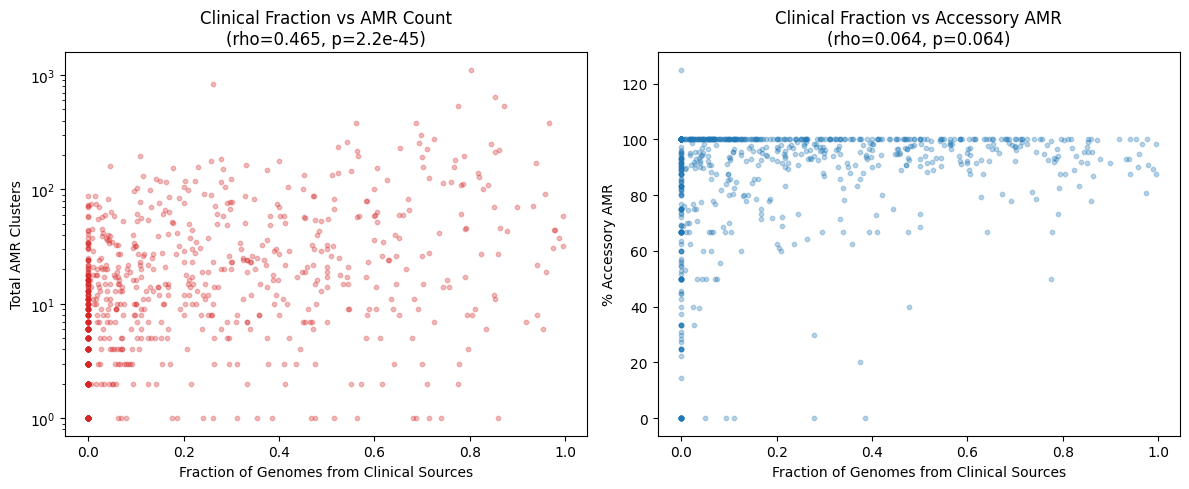

Saved to figures/h4_within_species.png


In [9]:
# Figure: clinical fraction vs AMR count and accessory fraction
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: clinical fraction vs total AMR
ax = axes[0]
ax.scatter(ws_df['clinical_frac'], ws_df['n_total_amr'],
           alpha=0.3, s=10, c='tab:red')
ax.set_xlabel('Fraction of Genomes from Clinical Sources')
ax.set_ylabel('Total AMR Clusters')
ax.set_title(f'Clinical Fraction vs AMR Count\n(rho={r2:.3f}, p={p2:.2g})')
ax.set_yscale('log')

# Right: clinical fraction vs %accessory
ax = axes[1]
ax.scatter(ws_df['clinical_frac'], ws_df['pct_accessory'],
           alpha=0.3, s=10, c='tab:blue')
ax.set_xlabel('Fraction of Genomes from Clinical Sources')
ax.set_ylabel('% Accessory AMR')
ax.set_title(f'Clinical Fraction vs Accessory AMR\n(rho={r:.3f}, p={p:.2g})')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'h4_within_species.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved to figures/h4_within_species.png')

In [10]:
# Save
ws_df.to_csv(os.path.join(DATA, 'within_species_amr_environment.csv'), index=False)

print(f'=== NB03 Summary ===')
print(f'Qualifying species: {len(ws_df)}')
print(f'H4 (clinical frac vs accessory AMR): rho={r:.4f}, p={p:.4g}')
print(f'H4 (clinical frac vs total AMR): rho={r2:.4f}, p={p2:.4g}')
if len(clinical_dom) >= 5 and len(env_dom) >= 5:
    print(f'Clinical-dominated vs environmental-dominated:')
    print(f'  Total AMR: {clinical_dom["n_total_amr"].mean():.1f} vs {env_dom["n_total_amr"].mean():.1f} (p={p3:.4g})')
    print(f'  %Accessory: {clinical_dom["pct_accessory"].mean():.1f}% vs {env_dom["pct_accessory"].mean():.1f}% (p={p4:.4g})')

=== NB03 Summary ===
Qualifying species: 823
H4 (clinical frac vs accessory AMR): rho=0.0645, p=0.06445
H4 (clinical frac vs total AMR): rho=0.4650, p=2.211e-45
Clinical-dominated vs environmental-dominated:
  Total AMR: 72.9 vs 16.4 (p=2.006e-18)
  %Accessory: 93.6% vs 81.7% (p=0.004307)
